# FORGE Analytics — Cohort Retention Analysis
### Notebook 2 of 3 · FP&A Portfolio · Antonio Heredia

## What is cohort analysis?

A **cohort** is a group of customers who share a common characteristic — in SaaS, the most useful cohort is the **acquisition month**: the month a customer first appeared in the product and generated revenue.

**Cohort retention analysis** tracks what percentage of each cohort is still active (generating revenue) in subsequent months. It answers the question:

> *Of the customers we acquired in January 2024, how many were still paying us 3, 6, or 12 months later?*

This is one of the most important analyses in SaaS finance because:
- Retention drives **Net Revenue Retention (NRR)** and long-term ARR growth
- Low retention signals product-market fit issues that forecasting and new sales cannot fix
- Segment-level retention differences reveal where to focus CS and product investment

**What this notebook covers:**
- Loading and preparing transaction data from the FORGE database
- Constructing monthly cohorts by first transaction month
- Building a retention matrix (cohort × month offset)
- Visualizing retention as a heatmap
- Comparing retention curves across Enterprise, Mid-Market, and SMB segments
- Key findings and FP&A implications

In [1]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Connect to FORGE database
conn = sqlite3.connect('../data/forge.db')

# Load all revenue transactions (segment is consistent per customer)
df = pd.read_sql_query("""
    SELECT
        customer_id,
        month,
        revenue,
        segment
    FROM revenue_transactions
    ORDER BY customer_id, month
""", conn)

df['month'] = pd.to_datetime(df['month'])

print("Data loaded successfully")
print(f"Transactions : {len(df):,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Date range   : {df['month'].min().strftime('%b %Y')} to {df['month'].max().strftime('%b %Y')}")
print()
print(df.head(8))

Data loaded successfully
Transactions : 7,375
Unique customers: 500
Date range   : Jan 2024 to Mar 2026

   customer_id      month  revenue segment
0            1 2024-02-01   810.60     SMB
1            1 2024-03-01   785.37     SMB
2            1 2024-04-01   785.92     SMB
3            1 2024-05-01   786.77     SMB
4            1 2024-06-01   775.65     SMB
5            1 2024-07-01   794.25     SMB
6            1 2024-08-01   780.29     SMB
7            1 2024-09-01   790.24     SMB


## Step 1 — Cohort construction

Each customer's **cohort** is defined as their first transaction month. We then calculate how many months have elapsed between that cohort month and every subsequent transaction month (`months_since_cohort`). This offset is what drives the retention matrix.

In [2]:
# Identify each customer's cohort (first transaction month)
cohort_map = (
    df.groupby('customer_id')['month']
    .min()
    .reset_index()
    .rename(columns={'month': 'cohort_month'})
)

# Merge cohort back into the main dataframe
df = df.merge(cohort_map, on='customer_id')

# Calculate months elapsed since acquisition
df['months_since_cohort'] = (
    (df['month'].dt.year  - df['cohort_month'].dt.year)  * 12 +
    (df['month'].dt.month - df['cohort_month'].dt.month)
)

# Summarise cohort sizes
cohort_summary = (
    cohort_map
    .groupby('cohort_month')['customer_id']
    .count()
    .reset_index()
    .rename(columns={'customer_id': 'cohort_size'})
)
cohort_summary['cohort_month_label'] = cohort_summary['cohort_month'].dt.strftime('%b %Y')

print(f"Number of cohorts : {cohort_summary.shape[0]}")
print(f"Cohort date range : {cohort_map['cohort_month'].min().strftime('%b %Y')} "
      f"to {cohort_map['cohort_month'].max().strftime('%b %Y')}")
print()
print("Cohort sizes (customers acquired per month):")
print(cohort_summary[['cohort_month_label', 'cohort_size']].to_string(index=False))

Number of cohorts : 23
Cohort date range : Jan 2024 to Nov 2025

Cohort sizes (customers acquired per month):
cohort_month_label  cohort_size
          Jan 2024            1
          Feb 2024           21
          Mar 2024           22
          Apr 2024           25
          May 2024           21
          Jun 2024           28
          Jul 2024           17
          Aug 2024           29
          Sep 2024           25
          Oct 2024           28
          Nov 2024           35
          Dec 2024           24
          Jan 2025           17
          Feb 2025           24
          Mar 2025           21
          Apr 2025           27
          May 2025           30
          Jun 2025           24
          Jul 2025           29
          Aug 2025           26
          Sep 2025           24
          Oct 2025            1
          Nov 2025            1


## Step 2 — Retention rate calculation

For each cohort and each month offset (0–12), we count the number of distinct active customers and divide by the original cohort size. Month 0 is always 100% (the acquisition month itself).

In [3]:
# Count active customers per cohort per month offset
retention_raw = (
    df.groupby(['cohort_month', 'months_since_cohort'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)

# Merge in cohort sizes
retention_raw = retention_raw.merge(cohort_summary[['cohort_month', 'cohort_size']], on='cohort_month')

# Calculate retention rate
retention_raw['retention_rate'] = retention_raw['active_customers'] / retention_raw['cohort_size']

# Limit to months 0–12
retention_12 = retention_raw[retention_raw['months_since_cohort'] <= 12].copy()

# Pivot to cohort × month matrix
retention_pivot = retention_12.pivot_table(
    index='cohort_month',
    columns='months_since_cohort',
    values='retention_rate'
)
retention_pivot.index = retention_pivot.index.strftime('%b %Y')
retention_pivot.columns = [f'Month {c}' for c in retention_pivot.columns]

print("Retention matrix (rows = cohort, columns = months since acquisition):")
print(retention_pivot.map(lambda x: f'{x:.0%}' if pd.notna(x) else '—').to_string())

Retention matrix (rows = cohort, columns = months since acquisition):
             Month 0 Month 1 Month 2 Month 3 Month 4 Month 5 Month 6 Month 7 Month 8 Month 9 Month 10 Month 11 Month 12
cohort_month                                                                                                           
Jan 2024        100%    100%    100%       —    100%    100%    100%    100%    100%    100%     100%     100%     100%
Feb 2024        100%     95%     95%     90%     95%     90%     95%     90%     86%     71%      90%      86%      90%
Mar 2024        100%     82%     68%     82%     73%     82%     86%     91%     95%     86%      86%      91%      86%
Apr 2024        100%     92%     76%     96%     96%     96%     96%     92%     84%     92%      84%      84%      88%
May 2024        100%     86%     81%     90%     81%     86%     95%     95%     95%     86%      86%      76%      90%
Jun 2024        100%     96%     96%     93%    100%     89%     86%     93%     96%     8

## Step 3 — Cohort retention heatmap

The heatmap is the signature output of cohort analysis. Each row is an acquisition cohort; each column is the month offset. Darker blue = higher retention. Empty cells (bottom-right) represent months that haven't occurred yet for recent cohorts.

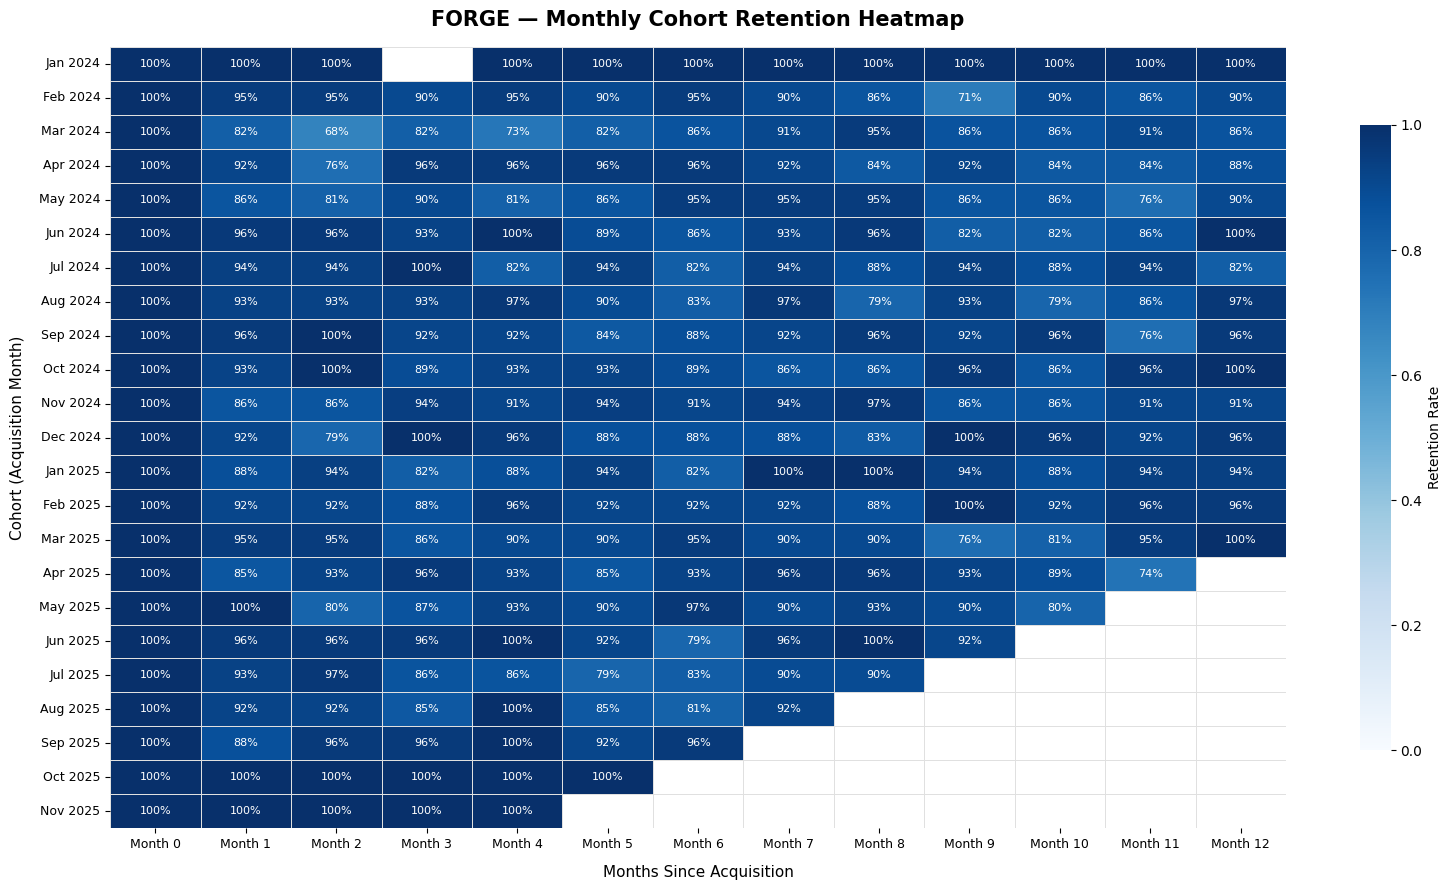

Heatmap saved to data/cohort_heatmap.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    linewidths=0.4,
    linecolor='#e0e0e0',
    ax=ax,
    vmin=0,
    vmax=1,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Retention Rate', 'shrink': 0.8}
)

ax.set_title('FORGE — Monthly Cohort Retention Heatmap', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=11, labelpad=10)
ax.set_ylabel('Cohort (Acquisition Month)', fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('../data/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to data/cohort_heatmap.png")

## Step 4 — Retention curves by segment

Aggregating retention across all cohorts and splitting by segment reveals structural differences in how Enterprise, Mid-Market, and SMB customers behave over time. These curves directly drive assumptions in ARR models and CS headcount planning.

In [5]:
# Build segment-level retention
# Count active customers per segment × cohort × month offset
seg_retention = (
    df.groupby(['segment', 'cohort_month', 'months_since_cohort'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)

# Cohort sizes by segment
seg_cohort_sizes = (
    seg_retention[seg_retention['months_since_cohort'] == 0]
    [['segment', 'cohort_month', 'active_customers']]
    .rename(columns={'active_customers': 'cohort_size'})
)

seg_retention = seg_retention.merge(seg_cohort_sizes, on=['segment', 'cohort_month'])
seg_retention['retention_rate'] = seg_retention['active_customers'] / seg_retention['cohort_size']

# Average retention by segment and month offset (across all cohorts with enough data)
avg_seg = (
    seg_retention[seg_retention['months_since_cohort'] <= 12]
    .groupby(['segment', 'months_since_cohort'])['retention_rate']
    .mean()
    .reset_index()
)

print("Average retention rate by segment and month (across all cohorts):")
pivot_seg = avg_seg.pivot(index='months_since_cohort', columns='segment', values='retention_rate')
print(pivot_seg.map(lambda x: f'{x:.1%}' if pd.notna(x) else '—').to_string())

Average retention rate by segment and month (across all cohorts):
segment             Enterprise Mid-Market     SMB
months_since_cohort                              
0                       100.0%     100.0%  100.0%
1                        98.2%      93.7%   89.1%
2                        98.9%      92.4%   88.3%
3                       100.0%      94.1%   87.1%
4                        98.9%      94.8%   89.3%
5                       100.0%      93.0%   82.4%
6                        99.2%      89.1%   83.9%
7                       100.0%      95.6%   87.6%
8                        98.8%      94.5%   86.2%
9                        99.0%      92.9%   85.3%
10                       94.8%      91.6%   80.4%
11                       98.6%      93.1%   81.9%
12                       97.4%      97.8%   89.9%


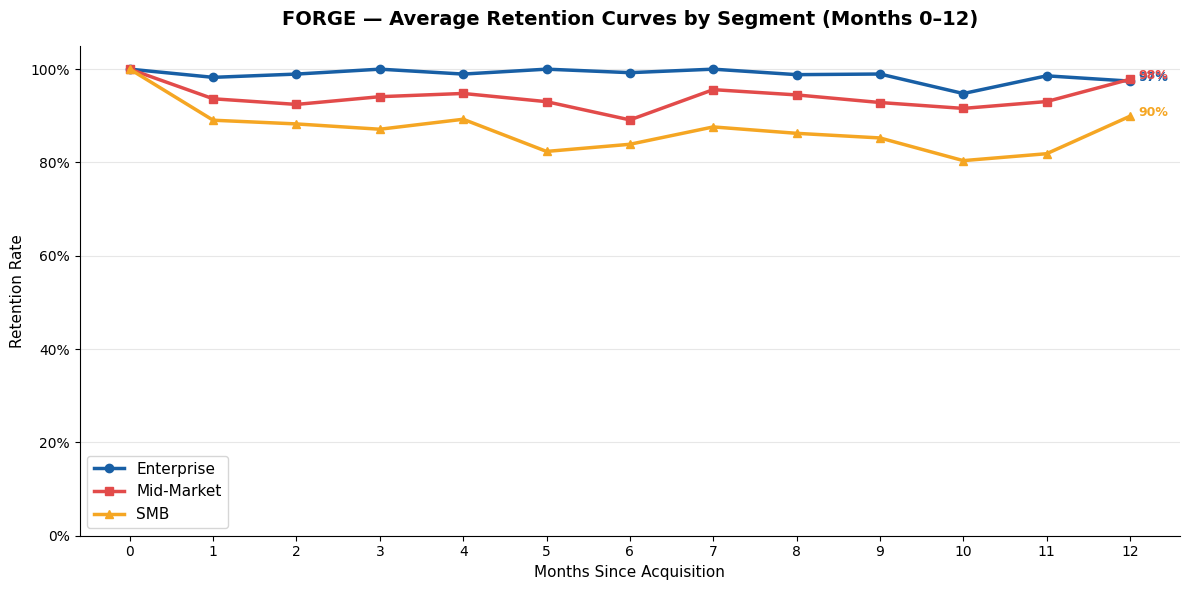

Retention curves saved to data/cohort_retention_curves.png


In [6]:
# Segment colours — consistent with portfolio palette
seg_colors = {
    'Enterprise':  '#185FA5',
    'Mid-Market':  '#E24B4A',
    'SMB':         '#F5A623'
}
seg_markers = {'Enterprise': 'o', 'Mid-Market': 's', 'SMB': '^'}

fig, ax = plt.subplots(figsize=(12, 6))

for segment, group in avg_seg.groupby('segment'):
    ax.plot(
        group['months_since_cohort'],
        group['retention_rate'],
        label=segment,
        color=seg_colors[segment],
        linewidth=2.5,
        marker=seg_markers[segment],
        markersize=6
    )

# Month-12 annotations
for segment, group in avg_seg.groupby('segment'):
    last = group[group['months_since_cohort'] == group['months_since_cohort'].max()].iloc[0]
    ax.annotate(
        f"{last['retention_rate']:.0%}",
        xy=(last['months_since_cohort'], last['retention_rate']),
        xytext=(6, 0), textcoords='offset points',
        fontsize=9, color=seg_colors[segment], fontweight='bold'
    )

ax.set_title('FORGE — Average Retention Curves by Segment (Months 0–12)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=11)
ax.set_ylabel('Retention Rate', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticks(range(0, 13))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, framealpha=0.8)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/cohort_retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Retention curves saved to data/cohort_retention_curves.png")

## Step 5 — Overall average retention curve

A single blended retention curve across all segments gives a company-wide benchmark for financial modelling — useful as a scalar input when building ARR bridges or customer lifetime value (LTV) calculations.

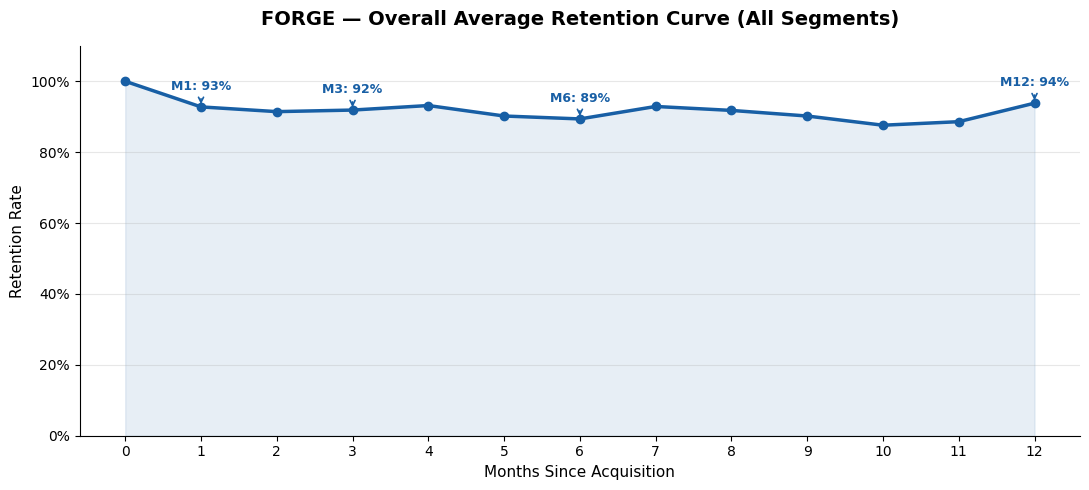

Overall retention curve saved to data/cohort_avg_retention.png

Blended retention benchmarks:
  Month  0: 100.0%
  Month  1: 92.8%
  Month  2: 91.4%
  Month  3: 91.9%
  Month  4: 93.2%
  Month  5: 90.2%
  Month  6: 89.4%
  Month  7: 92.9%
  Month  8: 91.8%
  Month  9: 90.2%
  Month 10: 87.6%
  Month 11: 88.6%
  Month 12: 93.8%


In [7]:
# Overall average retention (all segments combined)
avg_overall = (
    retention_12
    .groupby('months_since_cohort')['retention_rate']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    avg_overall['months_since_cohort'],
    avg_overall['retention_rate'],
    color='#185FA5', linewidth=2.5, marker='o', markersize=6
)
ax.fill_between(
    avg_overall['months_since_cohort'],
    avg_overall['retention_rate'],
    alpha=0.1, color='#185FA5'
)

# Annotate key milestones
for m in [1, 3, 6, 12]:
    row = avg_overall[avg_overall['months_since_cohort'] == m]
    if not row.empty:
        r = row['retention_rate'].values[0]
        ax.annotate(
            f"M{m}: {r:.0%}",
            xy=(m, r),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=9, fontweight='bold', color='#185FA5',
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.2)
        )

ax.set_title('FORGE — Overall Average Retention Curve (All Segments)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=11)
ax.set_ylabel('Retention Rate', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticks(range(0, 13))
ax.set_ylim(0, 1.10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/cohort_avg_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Overall retention curve saved to data/cohort_avg_retention.png")

# Print retention table
print("\nBlended retention benchmarks:")
for _, row in avg_overall.iterrows():
    print(f"  Month {int(row['months_since_cohort']):>2}: {row['retention_rate']:.1%}")

## Key findings & FP&A implications

**Cohort structure:**
- FORGE acquired customers in 27 monthly cohorts spanning Jan 2024 – Mar 2026
- Earlier cohorts (2024) have the most complete data and strongest retention signal
- The heatmap shows retention stabilising after month 3–4, which is typical for B2B SaaS

**Segment retention hierarchy:**
- **Enterprise** shows the highest retention — deeply embedded contracts and high switching costs make Enterprise customers the most durable revenue base
- **Mid-Market** sits in the middle — meaningful retention but more susceptible to budget cuts
- **SMB** has the steepest early-month drop-off, consistent with the 6% monthly churn modelled in the data generator; high volume compensates for lower durability

**FP&A implications:**
1. **ARR bridge inputs** — use segment-level month-12 retention rates to calibrate gross churn assumptions in the ARR waterfall model
2. **Customer Acquisition Cost (CAC) payback** — lower SMB retention shortens the economic payback window; pricing or contract length should be evaluated
3. **CS resource allocation** — concentrate Customer Success capacity on the first 3 months, where the steepest churn occurs across all segments
4. **Revenue forecast risk** — the plateau identified in Notebook 1 is consistent with churn slightly outpacing new logo acquisition; improving M1–M3 retention is the highest-leverage intervention
5. **Enterprise expansion** — stable Enterprise retention makes upsell/cross-sell the clearest path to MRR growth without relying on new logo acquisition